In [5]:
# ============================================================
# MAD Risk Score: Geometry Fix Experiment
# Replacing LID with Mean Distance to Centroid (MDC)
# CLIP ViT-L/14, Fitzpatrick17k + DDI + PH2 + PAD-UFES-20
# GPU T4, Internet ON. ~2 hours.
#
# CONTEXT:
#   The original MAD Risk Score formula:
#     MAD_risk = (1 − μcosine) / log(1 + n_minority_train)
#   produces false positives on DDI and PH2 because it captures
#   numerical rarity (n_min) and mean pairwise similarity (μcosine)
#   but not whether the minority class forms a geometrically tight
#   cluster vs. a diffuse high-dimensional cloud.
#
#   A prior experiment tested Local Intrinsic Dimensionality (LID)
#   as the missing term. LID produced PARTIAL SEPARATION only:
#   Fitzpatrick17k (TP) LID=6.375 ≈ DDI (FP) LID=6.370 —
#   indistinguishable. Two issues were identified:
#     (1) PAD-UFES-20 was not filtered to dark-skin only (used all
#         2298 samples instead of ~73), making its geometry numbers
#         invalid.
#     (2) LID at k=20 in cosine space washes out local cluster
#         tightness for small classes (DDI n=48, PH2 n=19).
#
#   This experiment replaces LID with Mean Distance to Centroid
#   (MDC): the average L2 distance of each minority-class sample
#   from the class mean embedding. This directly operationalizes
#   the mechanism described in the manuscript:
#     - Melanoma in DDI: visually distinctive, tight cluster → low MDC
#     - Benign lesions in Fitzpatrick17k dark-skin: heterogeneous
#       presentation → high MDC
#   MDC requires no hyperparameter (no k), is computable in two lines
#   of numpy, and is directly interpretable.
#
#   CRITICAL FIX vs. prior notebook:
#   PAD-UFES-20 is filtered using the 'fitspatrick' column (note
#   the dataset's typo) to FST >= 5 (dark skin only), consistent
#   with the manuscript's n=73 dark-skin cohort.
#
# EXTENDED FORMULA CANDIDATE:
#   MAD_risk_ext(D,A) = MDC * (1 − μcosine) / log(1 + n_min)
#   where MDC = mean L2 distance of minority samples to class centroid.
#   Mechanistic interpretation:
#     High MDC = diffuse class = DRO cannot maintain gradient signal
#     Low MDC  = compact class = DRO retains gradient signal
#   Combined with (1−μ) and 1/log(1+n_min), this should score
#   TP datasets (diffuse, high MDC) above FP datasets (compact, low MDC).
#
# WE ALSO TEST:
#   - Fraction of variance explained by PC1 (PC1_var): a compact
#     class lies on one axis (high PC1 share); diffuse class spreads
#     across many (low PC1 share). High PC1_var → compact → FP.
#   - Silhouette-style within-class tightness vs. between-class
#     separation is expensive at 768 dims; MDC and PC1_var suffice.
#
# PRIMARY QUESTION:
#   Does MDC cleanly separate TP (collapse) from FP (no collapse)?
#   Specifically: does MDC(Fitzpatrick17k) > MDC(DDI)?
#   (This is the pair LID could not separate.)
#   If yes AND extended formula TP mean > FP mean with no overlap:
#     → Extended formula is empirically motivated. Reframe paper:
#       LID failed, diagnosed why, MDC succeeds, mechanism confirmed.
#   If no: the geometric-measure approach does not work on this data.
#     → Accept formula limitation. Path A only.
#
# DATASETS:
#   Fitzpatrick17k: dark-skin (FST V-VI) × benign [TRUE POSITIVE]
#   PAD-UFES-20:    FST >= 5 dark-skin ONLY — n~73 [TRUE POSITIVE]
#                   *** CRITICAL: filter on 'fitspatrick' col >= 5 ***
#   DDI:            FST V-VI malignant (n=48) [FALSE POSITIVE]
#   PH2:            melanoma cases IMD041-080 (n~19) [FALSE POSITIVE]
#
# OUTPUTS:
#   geometry_results.csv          — per-dataset MDC + PC1_var + scores
#   geometry_score_comparison.png — current vs extended score bar chart
#   geometry_pca_viz.png          — PCA of minority embeddings (4 datasets)
#   geometry_mdc_separation.png   — MDC values with TP/FP coloring
#   (+ LaTeX table rows + interpretation flags at end)
#
# Kaggle: GPU T4 x1, Internet ON
# Datasets: fitzpatrick17k, ddi-dataset, pad-ufes-20, ph2-dataset
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib -q

import torch
import numpy as np, pandas as pd, os, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.decomposition import PCA
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────
BASE_SEED  = 42
FEAT_DIM   = 768
BATCH_SIZE = 32

# Known values from manuscript (consistency checks)
KNOWN_MU = {
    'fitzpatrick17k': 0.712,
    'ddi':            0.715,
    'ph2':            0.873,
    'pad_ufes_20':    None,
}
KNOWN_N_MIN_TRAIN = {
    'fitzpatrick17k': 88,   # collapse boundary sweep midpoint
    'ddi':            48,
    'ph2':            21,
    'pad_ufes_20':    26,
}
GROUND_TRUTH_COLLAPSE = {
    'fitzpatrick17k': True,
    'ddi':            False,
    'ph2':            False,
    'pad_ufes_20':    True,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
np.random.seed(BASE_SEED)

Device: cuda


In [6]:
# ── Load CLIP once ────────────────────────────────────────────
print('Loading CLIP ViT-L/14...')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(device)
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
clip_model.eval()
print('CLIP loaded.')

@torch.no_grad()
def get_features(images, batch_size=BATCH_SIZE):
    """Extract L2-normalized CLIP ViT-L/14 features. Identical to primary notebooks."""
    all_feats = []
    for i in range(0, len(images), batch_size):
        batch  = images[i:i+batch_size]
        inputs = clip_proc(images=batch, return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        feats  = clip_model.get_image_features(**inputs)
        if not isinstance(feats, torch.Tensor):
            feats = feats.pooler_output if hasattr(feats, 'pooler_output') \
                    else feats.last_hidden_state[:, 0]
        feats  = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().numpy())
    return np.vstack(all_feats)

def load_images_from_paths(paths, max_n=None):
    imgs, valid = [], []
    if max_n is not None:
        paths = paths[:max_n]
    for p in paths:
        try:
            img = Image.open(p).convert('RGB').resize((224, 224))
            imgs.append(img)
            valid.append(p)
        except Exception:
            pass
    return imgs, valid

print('Feature extraction helpers defined.')

Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Feature extraction helpers defined.


In [7]:
# ── Geometry measures ─────────────────────────────────────────
#
# MDC (Mean Distance to Centroid):
#   centroid = mean of all minority-class L2-normalized embeddings
#   MDC = mean L2 distance of each sample to the centroid
#   Compact class → low MDC. Diffuse class → high MDC.
#   No hyperparameter. Interpretable. Directly maps to the manuscript's
#   mechanistic claim about geometric compactness.
#
# Note on L2 vs cosine distance:
#   Features are L2-normalized (unit sphere). On the unit sphere,
#   L2 distance and cosine distance are monotonically related:
#   L2(a,b)^2 = 2(1 − cos(a,b)). We use L2 because it gives the
#   Euclidean distance in the ambient space, which is more intuitive
#   for cluster radius. Results are equivalent up to monotone transform.
#
# PC1_var (Fraction of variance explained by first principal component):
#   PCA on minority-class features. A compact, elongated cluster
#   (like melanoma) lies mostly on one axis → high PC1 share.
#   A diffuse, isotropic cloud (like heterogeneous benign) spreads
#   across many axes → low PC1 share.
#   NOTE: high PC1_var = compact = FP (no collapse).
#         low PC1_var  = diffuse = TP (collapse).
#   This is the OPPOSITE sign from MDC.

def compute_mdc(features):
    """
    Mean Distance to Centroid (L2).
    features: np.ndarray (n, d), L2-normalized.
    Returns: (mdc_mean, mdc_std, centroid)
    """
    if len(features) < 2:
        return np.nan, np.nan, None
    centroid = features.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-10)  # re-normalize centroid
    dists    = np.linalg.norm(features - centroid, axis=1)
    return float(np.mean(dists)), float(np.std(dists)), centroid

def compute_pc1_var(features):
    """
    Fraction of variance explained by first principal component.
    High = compact (cluster lies on one axis).
    Low  = diffuse (spread across many axes).
    """
    if len(features) < 3:
        return np.nan
    pca = PCA(n_components=min(10, len(features)-1, features.shape[1]),
              random_state=BASE_SEED)
    pca.fit(features)
    return float(pca.explained_variance_ratio_[0])

def compute_mu_cosine(features):
    """Mean pairwise cosine similarity. Caps at 5000 pairs."""
    n = len(features)
    if n < 2:
        return float('nan')
    if n > 5000:
        idx = np.random.RandomState(BASE_SEED).choice(n, 5000, replace=False)
        features = features[idx]
        n = 5000
    sim = features @ features.T
    upper = sim[np.triu_indices(n, k=1)]
    return float(np.mean(upper))

def mad_risk_current(mu_cosine, n_min_train):
    """Original formula: (1 − μ) / log(1 + n_min)"""
    if n_min_train <= 0 or np.isnan(mu_cosine):
        return np.nan
    return (1.0 - mu_cosine) / np.log(1.0 + n_min_train)

def mad_risk_extended(mdc, mu_cosine, n_min_train):
    """
    Extended formula: MDC * (1 − μ) / log(1 + n_min)
    Mechanistic reading:
      - MDC captures geometric diffuseness of the minority class.
        Diffuse (high MDC) + heterogeneous (high 1-μ) + rare (low n_min)
        = DRO cannot maintain gradient signal = collapse.
      - Compact class (low MDC, e.g. melanoma in DDI) → low score
        regardless of numerical rarity → no collapse predicted.
    Note: MDC is on a different scale than the original formula.
    Threshold requires recalibration on sweep data (future work).
    This experiment tests ordinal separation only.
    """
    if np.isnan(mdc) or np.isnan(mu_cosine) or n_min_train <= 0:
        return np.nan
    return mdc * (1.0 - mu_cosine) / np.log(1.0 + n_min_train)

print('Geometry measures defined.')
print()
print('MDC interpretation: HIGH = diffuse = collapse expected (TP)')
print('                    LOW  = compact = no collapse expected (FP)')
print('PC1_var interpretation: HIGH = compact = no collapse (FP)')
print('                        LOW  = diffuse = collapse (TP)')

Geometry measures defined.

MDC interpretation: HIGH = diffuse = collapse expected (TP)
                    LOW  = compact = no collapse expected (FP)
PC1_var interpretation: HIGH = compact = no collapse (FP)
                        LOW  = diffuse = collapse (TP)


In [8]:
# ── Dataset 1: Fitzpatrick17k — dark-skin benign [TRUE POSITIVE] ──
# Minority class: FST V-VI × benign (n=203, nc/Ng=9.4%)
# 5/5 DRO weight collapse confirmed.
# Mechanistic claim: benign lesions in dark skin are visually
# heterogeneous → high MDC expected.

print('=' * 60)
print('Dataset 1: Fitzpatrick17k [TRUE POSITIVE]')
print('=' * 60)

_fitz_csv = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_root, _f)
            break
    if _fitz_csv: break
if not _fitz_csv:
    _fitz_csv = '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
print(f'CSV: {_fitz_csv}')

fitz_df = pd.read_csv(_fitz_csv)
fitz_df = fitz_df[fitz_df['fitzpatrick_scale'] > 0]

fitz_img_dir = os.path.dirname(_fitz_csv)
image_files  = {}
for _r, _d, _fs in os.walk(fitz_img_dir):
    for _f in _fs:
        if _f.endswith(('.jpg', '.png')):
            image_files[_f.rsplit('.', 1)[0]] = os.path.join(_r, _f)

fitz_df['local_path'] = fitz_df['md5hash'].map(image_files)
fitz_df = fitz_df[fitz_df['local_path'].notna()]

fitz_min = fitz_df[
    (fitz_df['fitzpatrick_scale'] >= 5) &
    (fitz_df['three_partition_label'] == 'benign')
].copy()
print(f'Minority (dark×benign): n={len(fitz_min)}')

fitz_imgs, _ = load_images_from_paths(fitz_min['local_path'].tolist())
fitz_feats   = get_features(fitz_imgs)
print(f'Features: {fitz_feats.shape}')

fitz_mdc, fitz_mdc_std, _ = compute_mdc(fitz_feats)
fitz_pc1  = compute_pc1_var(fitz_feats)
fitz_mu   = compute_mu_cosine(fitz_feats)

print(f'  MDC (mean dist to centroid): {fitz_mdc:.4f} ± {fitz_mdc_std:.4f}')
print(f'  PC1 variance share:          {fitz_pc1:.4f}')
print(f'  μcosine:                     {fitz_mu:.4f}  (manuscript: {KNOWN_MU["fitzpatrick17k"]})')
print(f'  Current MAD_risk:            {mad_risk_current(fitz_mu, KNOWN_N_MIN_TRAIN["fitzpatrick17k"]):.4f}')
print(f'  Extended MAD_risk (MDC):     {mad_risk_extended(fitz_mdc, fitz_mu, KNOWN_N_MIN_TRAIN["fitzpatrick17k"]):.4f}')

Dataset 1: Fitzpatrick17k [TRUE POSITIVE]
CSV: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Minority (dark×benign): n=203
Features: (203, 768)
  MDC (mean dist to centroid): 0.5514 ± 0.0796
  PC1 variance share:          0.2112
  μcosine:                     0.7123  (manuscript: 0.712)
  Current MAD_risk:            0.0641
  Extended MAD_risk (MDC):     0.0353


In [9]:
# ── Dataset 2: PAD-UFES-20 — dark-skin FST>=5 ONLY [TRUE POSITIVE] ──
#
# CRITICAL FIX from prior notebook:
# The dataset has a column named 'fitspatrick' (typo in dataset).
# Filter to fitspatrick >= 5 to match the manuscript's dark-skin
# cohort (n~73). The prior experiment used ALL 2298 samples,
# making every geometry number for this dataset invalid.
#
# Column list from prior run:
# ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father',
#  'background_mother', 'age', 'pesticide', 'gender',
#  'skin_cancer_history', 'cancer_history', 'has_piped_water',
#  'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
#  'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed',
#  'bleed', 'elevation', 'img_id', 'biopsed']
# FST column = 'fitspatrick' (note the typo — one 'z' not two)

print('=' * 60)
print('Dataset 2: PAD-UFES-20 [TRUE POSITIVE]')
print('CRITICAL: filtering to fitspatrick >= 5 (dark skin only)')
print('=' * 60)

_pad_csv = '/kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv'
print(f'CSV: {_pad_csv}')

pad_df = pd.read_csv(_pad_csv)
print(f'Total rows: {len(pad_df)}')
print(f'Columns: {list(pad_df.columns)}')

# Verify 'fitspatrick' column exists
fst_col = 'fitspatrick'
if fst_col not in pad_df.columns:
    # Try common variants
    fst_col = next((c for c in pad_df.columns
                    if 'fitz' in c.lower() or 'fits' in c.lower()), None)
    if fst_col is None:
        print('ERROR: no FST column found. Check column names above.')

print(f'FST column: "{fst_col}"')
print(f'FST value distribution:')
print(pad_df[fst_col].value_counts().sort_index().to_string())

# Filter dark skin: fitspatrick >= 5
pad_dark = pad_df[pad_df[fst_col] >= 5].copy()
print(f'\nDark-skin (fitspatrick >= 5): n={len(pad_dark)}')
print(f'  (Manuscript reports n=73 dark-skin test images)')

# Resolve image paths
pad_img_dir = os.path.dirname(_pad_csv)
pad_img_files = {}
for _r, _d, _fs in os.walk(pad_img_dir):
    for _f in _fs:
        if _f.endswith(('.jpg', '.png', '.jpeg')):
            pad_img_files[_f] = os.path.join(_r, _f)
print(f'Image files found: {len(pad_img_files)}')

img_col = 'img_id'  # confirmed from prior run column list
pad_dark['local_path'] = pad_dark[img_col].apply(
    lambda x: pad_img_files.get(str(x),
              pad_img_files.get(str(x) + '.jpg',
              pad_img_files.get(str(x) + '.png', None)))
)
pad_dark = pad_dark[pad_dark['local_path'].notna()]
print(f'Paths resolved: {len(pad_dark)}')

if len(pad_dark) == 0:
    print('WARNING: No dark-skin PAD-UFES-20 images loaded.')
    print('Check that fitspatrick >= 5 yields images and paths resolve.')
    pad_feats   = np.zeros((0, FEAT_DIM))
    pad_mdc     = np.nan; pad_mdc_std = np.nan
    pad_pc1     = np.nan; pad_mu      = np.nan
else:
    pad_imgs, _ = load_images_from_paths(pad_dark['local_path'].tolist())
    print(f'Images loaded: {len(pad_imgs)}')
    pad_feats = get_features(pad_imgs)
    print(f'Features: {pad_feats.shape}')

    pad_mdc, pad_mdc_std, _ = compute_mdc(pad_feats)
    pad_pc1 = compute_pc1_var(pad_feats)
    pad_mu  = compute_mu_cosine(pad_feats)

    print(f'  MDC (mean dist to centroid): {pad_mdc:.4f} ± {pad_mdc_std:.4f}')
    print(f'  PC1 variance share:          {pad_pc1:.4f}')
    print(f'  μcosine:                     {pad_mu:.4f}')
    print(f'  Current MAD_risk:            {mad_risk_current(pad_mu, KNOWN_N_MIN_TRAIN["pad_ufes_20"]):.4f}')
    print(f'  Extended MAD_risk (MDC):     {mad_risk_extended(pad_mdc, pad_mu, KNOWN_N_MIN_TRAIN["pad_ufes_20"]):.4f}')
    print(f'  n={len(pad_feats)} (manuscript: ~73)')

Dataset 2: PAD-UFES-20 [TRUE POSITIVE]
CRITICAL: filtering to fitspatrick >= 5 (dark skin only)
CSV: /kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv
Total rows: 2298
Columns: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']
FST column: "fitspatrick"
FST value distribution:
fitspatrick
1.0    153
2.0    876
3.0    392
4.0     62
5.0     10
6.0      1

Dark-skin (fitspatrick >= 5): n=11
  (Manuscript reports n=73 dark-skin test images)
Image files found: 2298
Paths resolved: 11
Images loaded: 11
Features: (11, 768)
  MDC (mean dist to centroid): 0.4416 ± 0.0536
  PC1 variance share:          0.2126
  μcosine:                     0.7931
  Current MAD_risk:            0.0628
  Extended MA

In [10]:
# ── Dataset 3: DDI — FST V-VI malignant [FALSE POSITIVE] ──────
# Minority class: FST V-VI × malignant (n=48, nc/Ng=23.2%)
# 0/5 DRO collapse. Mechanistic claim: melanoma is visually
# distinctive, forms a tight CLIP feature cluster → low MDC expected.
# This is the pair that was indistinguishable from Fitzpatrick17k
# under LID (6.375 vs 6.370). MDC must separate them to succeed.

print('=' * 60)
print('Dataset 3: DDI [FALSE POSITIVE]')
print('KEY TEST: MDC(DDI) must be < MDC(Fitzpatrick17k)')
print('=' * 60)

_ddi_csv = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.endswith('.csv') and 'ddi' in _f.lower():
            _ddi_csv = os.path.join(_root, _f)
            break
    if _ddi_csv: break
if not _ddi_csv:
    _ddi_csv = '/kaggle/input/ddi-dataset/ddi_metadata.csv'
print(f'CSV: {_ddi_csv}')

ddi_df = pd.read_csv(_ddi_csv)
print(f'Columns: {list(ddi_df.columns)}')
print(f'Unique skin_tone values: {sorted(ddi_df["skin_tone"].unique()) if "skin_tone" in ddi_df.columns else "N/A"}')
print(f'Unique malignant values: {sorted(ddi_df["malignant"].unique()) if "malignant" in ddi_df.columns else "N/A"}')

ddi_img_dir = os.path.dirname(_ddi_csv)
ddi_img_files = {}
for _r, _d, _fs in os.walk(ddi_img_dir):
    for _f in _fs:
        if _f.endswith(('.jpg', '.png', '.jpeg')):
            ddi_img_files[_f] = os.path.join(_r, _f)
print(f'Image files: {len(ddi_img_files)}')

# DDI has skin_tone column: values 12, 34, 56 (FST group pairs)
# FST V-VI = skin_tone == 56
# malignant column: True/False boolean
if 'skin_tone' in ddi_df.columns and 'malignant' in ddi_df.columns:
    ddi_min = ddi_df[
        (ddi_df['skin_tone'] == 56) &
        (ddi_df['malignant'] == True)
    ].copy()
    if len(ddi_min) == 0:
        # Try string 'True' or 1
        ddi_min = ddi_df[
            (ddi_df['skin_tone'] == 56) &
            (ddi_df['malignant'].astype(str).str.lower().isin(['true', '1']))
        ].copy()
else:
    print('WARNING: expected columns not found. Using all 48 malignant.')
    ddi_min = ddi_df.head(48).copy()

print(f'Minority (FST V-VI × malignant): n={len(ddi_min)}')

# Resolve image paths using DDI_file column
img_col = 'DDI_file' if 'DDI_file' in ddi_df.columns else \
          next((c for c in ddi_df.columns if 'file' in c.lower()), None)
ddi_min['local_path'] = ddi_min[img_col].apply(
    lambda x: ddi_img_files.get(str(x),
              ddi_img_files.get(os.path.basename(str(x)), None))
)
ddi_min = ddi_min[ddi_min['local_path'].notna()]
print(f'Paths resolved: {len(ddi_min)}')

ddi_imgs, _ = load_images_from_paths(ddi_min['local_path'].tolist())
ddi_feats   = get_features(ddi_imgs)
print(f'Features: {ddi_feats.shape}')

ddi_mdc, ddi_mdc_std, _ = compute_mdc(ddi_feats)
ddi_pc1 = compute_pc1_var(ddi_feats)
ddi_mu  = compute_mu_cosine(ddi_feats)

print(f'  MDC (mean dist to centroid): {ddi_mdc:.4f} ± {ddi_mdc_std:.4f}')
print(f'  PC1 variance share:          {ddi_pc1:.4f}')
print(f'  μcosine:                     {ddi_mu:.4f}  (manuscript: {KNOWN_MU["ddi"]})')
print(f'  Current MAD_risk:            {mad_risk_current(ddi_mu, KNOWN_N_MIN_TRAIN["ddi"]):.4f}')
print(f'  Extended MAD_risk (MDC):     {mad_risk_extended(ddi_mdc, ddi_mu, KNOWN_N_MIN_TRAIN["ddi"]):.4f}')
print()
print(f'  KEY CHECK: MDC(DDI)={ddi_mdc:.4f} < MDC(Fitzpatrick17k)={fitz_mdc:.4f}?  '
      f'{"YES ✓" if ddi_mdc < fitz_mdc else "NO ✗ — MDC does not separate this pair"}')

Dataset 3: DDI [FALSE POSITIVE]
KEY TEST: MDC(DDI) must be < MDC(Fitzpatrick17k)
CSV: /kaggle/input/datasets/culomb/ddi-diverse-dermatology-images/ddi_metadata.csv
Columns: ['Unnamed: 0', 'DDI_ID', 'DDI_file', 'skin_tone', 'malignant', 'disease']
Unique skin_tone values: [np.int64(12), np.int64(34), np.int64(56)]
Unique malignant values: [np.False_, np.True_]
Image files: 656
Minority (FST V-VI × malignant): n=48
Paths resolved: 48
Features: (48, 768)
  MDC (mean dist to centroid): 0.5452 ± 0.0791
  PC1 variance share:          0.1455
  μcosine:                     0.7136  (manuscript: 0.715)
  Current MAD_risk:            0.0736
  Extended MAD_risk (MDC):     0.0401

  KEY CHECK: MDC(DDI)=0.5452 < MDC(Fitzpatrick17k)=0.5514?  YES ✓


In [11]:
# ── Dataset 4: PH2 — melanoma [FALSE POSITIVE] ────────────────
# Melanoma cases: IMD041-080 (standard PH2 annotation, n≈40 total;
# ~19 after ITA-based dark-skin filter per manuscript).
# 0/5 DRO collapse. Same mechanism as DDI: melanoma compact in CLIP space.

print('=' * 60)
print('Dataset 4: PH2 [FALSE POSITIVE]')
print('=' * 60)

ph2_records = []
for _r, _d, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f.endswith('.bmp') and 'trainx' in _r.lower():
            _case = _f.split('_')[0]
            ph2_records.append({'image_id': _case,
                                 'local_path': os.path.join(_r, _f)})

ph2_df  = pd.DataFrame(ph2_records).drop_duplicates('image_id')
print(f'Total PH2 cases found: {len(ph2_df)}')

def is_melanoma(case_id):
    try:
        n = int(''.join(filter(str.isdigit, case_id)))
        return 41 <= n <= 80
    except:
        return False

ph2_min = ph2_df[ph2_df['image_id'].apply(is_melanoma)].copy()
print(f'Melanoma cases (IMD041-080): n={len(ph2_min)}')

ph2_imgs, _ = load_images_from_paths(ph2_min['local_path'].tolist())
ph2_feats   = get_features(ph2_imgs)
print(f'Features: {ph2_feats.shape}')

ph2_mdc, ph2_mdc_std, _ = compute_mdc(ph2_feats)
ph2_pc1 = compute_pc1_var(ph2_feats)
ph2_mu  = compute_mu_cosine(ph2_feats)

print(f'  MDC (mean dist to centroid): {ph2_mdc:.4f} ± {ph2_mdc_std:.4f}')
print(f'  PC1 variance share:          {ph2_pc1:.4f}')
print(f'  μcosine:                     {ph2_mu:.4f}  (manuscript: {KNOWN_MU["ph2"]})')
print(f'  Current MAD_risk:            {mad_risk_current(ph2_mu, KNOWN_N_MIN_TRAIN["ph2"]):.4f}')
print(f'  Extended MAD_risk (MDC):     {mad_risk_extended(ph2_mdc, ph2_mu, KNOWN_N_MIN_TRAIN["ph2"]):.4f}')

Dataset 4: PH2 [FALSE POSITIVE]
Total PH2 cases found: 200
Melanoma cases (IMD041-080): n=19
Features: (19, 768)
  MDC (mean dist to centroid): 0.3669 ± 0.0703
  PC1 variance share:          0.2409
  μcosine:                     0.8579  (manuscript: 0.873)
  Current MAD_risk:            0.0460
  Extended MAD_risk (MDC):     0.0169


In [12]:
# ── Compile results ────────────────────────────────────────────
results = [
    {'dataset': 'fitzpatrick17k', 'role': 'TP', 'collapse_observed': True,
     'n_minority': len(fitz_feats), 'n_min_train': KNOWN_N_MIN_TRAIN['fitzpatrick17k'],
     'mu_cosine': fitz_mu, 'mdc_mean': fitz_mdc, 'mdc_std': fitz_mdc_std,
     'pc1_var': fitz_pc1,
     'mad_risk_current':  mad_risk_current(fitz_mu,  KNOWN_N_MIN_TRAIN['fitzpatrick17k']),
     'mad_risk_extended': mad_risk_extended(fitz_mdc, fitz_mu, KNOWN_N_MIN_TRAIN['fitzpatrick17k'])},
    {'dataset': 'pad_ufes_20',    'role': 'TP', 'collapse_observed': True,
     'n_minority': len(pad_feats), 'n_min_train': KNOWN_N_MIN_TRAIN['pad_ufes_20'],
     'mu_cosine': pad_mu,  'mdc_mean': pad_mdc,  'mdc_std': pad_mdc_std,
     'pc1_var': pad_pc1,
     'mad_risk_current':  mad_risk_current(pad_mu,  KNOWN_N_MIN_TRAIN['pad_ufes_20']),
     'mad_risk_extended': mad_risk_extended(pad_mdc, pad_mu,  KNOWN_N_MIN_TRAIN['pad_ufes_20'])},
    {'dataset': 'ddi',            'role': 'FP', 'collapse_observed': False,
     'n_minority': len(ddi_feats), 'n_min_train': KNOWN_N_MIN_TRAIN['ddi'],
     'mu_cosine': ddi_mu,  'mdc_mean': ddi_mdc,  'mdc_std': ddi_mdc_std,
     'pc1_var': ddi_pc1,
     'mad_risk_current':  mad_risk_current(ddi_mu,  KNOWN_N_MIN_TRAIN['ddi']),
     'mad_risk_extended': mad_risk_extended(ddi_mdc, ddi_mu,  KNOWN_N_MIN_TRAIN['ddi'])},
    {'dataset': 'ph2',            'role': 'FP', 'collapse_observed': False,
     'n_minority': len(ph2_feats), 'n_min_train': KNOWN_N_MIN_TRAIN['ph2'],
     'mu_cosine': ph2_mu,  'mdc_mean': ph2_mdc,  'mdc_std': ph2_mdc_std,
     'pc1_var': ph2_pc1,
     'mad_risk_current':  mad_risk_current(ph2_mu,  KNOWN_N_MIN_TRAIN['ph2']),
     'mad_risk_extended': mad_risk_extended(ph2_mdc, ph2_mu,  KNOWN_N_MIN_TRAIN['ph2'])},
]

df_res = pd.DataFrame(results)
df_res.to_csv('/kaggle/working/geometry_results.csv', index=False)
print('=== GEOMETRY RESULTS SUMMARY ===')
print(df_res[['dataset', 'role', 'n_minority', 'mu_cosine',
              'mdc_mean', 'mdc_std', 'pc1_var',
              'mad_risk_current', 'mad_risk_extended']].to_string())

tp_rows = df_res[df_res['role'] == 'TP']
fp_rows = df_res[df_res['role'] == 'FP']

=== GEOMETRY RESULTS SUMMARY ===
          dataset role  n_minority  mu_cosine  mdc_mean   mdc_std   pc1_var  mad_risk_current  mad_risk_extended
0  fitzpatrick17k   TP         203   0.712331  0.551361  0.079552  0.211210          0.064088           0.035336
1     pad_ufes_20   TP          11   0.793079  0.441622  0.053585  0.212555          0.062783           0.027726
2             ddi   FP          48   0.713552  0.545209  0.079099  0.145471          0.073602           0.040129
3             ph2   FP          19   0.857867  0.366851  0.070279  0.240855          0.045982           0.016869


In [13]:
# ── Separation analysis ────────────────────────────────────────
print('=' * 60)
print('SEPARATION ANALYSIS')
print('=' * 60)

# MDC
tp_mdc = tp_rows['mdc_mean'].dropna()
fp_mdc = fp_rows['mdc_mean'].dropna()
print('\n[MDC — Mean Distance to Centroid]')
print(f'  TP datasets: {dict(zip(tp_rows["dataset"], tp_rows["mdc_mean"].round(4)))}')
print(f'  FP datasets: {dict(zip(fp_rows["dataset"], fp_rows["mdc_mean"].round(4)))}')
print(f'  TP mean: {tp_mdc.mean():.4f}  FP mean: {fp_mdc.mean():.4f}')
print(f'  TP > FP (expected): {tp_mdc.mean() > fp_mdc.mean()}')
print(f'  Clean separation (TP min > FP max): {tp_mdc.min() > fp_mdc.max()}')

# PC1_var
tp_pc1 = tp_rows['pc1_var'].dropna()
fp_pc1 = fp_rows['pc1_var'].dropna()
print('\n[PC1_var — Fraction of variance in first PC]')
print(f'  TP datasets: {dict(zip(tp_rows["dataset"], tp_rows["pc1_var"].round(4)))}')
print(f'  FP datasets: {dict(zip(fp_rows["dataset"], fp_rows["pc1_var"].round(4)))}')
print(f'  TP mean: {tp_pc1.mean():.4f}  FP mean: {fp_pc1.mean():.4f}')
print(f'  TP < FP (expected — compact FPs have higher PC1): {tp_pc1.mean() < fp_pc1.mean()}')

# Extended formula
tp_ext = tp_rows['mad_risk_extended'].dropna()
fp_ext = fp_rows['mad_risk_extended'].dropna()
print('\n[Extended MAD_risk = MDC × (1-μ) / log(1+n_min)]')
for _, r in df_res.iterrows():
    print(f'  {r["dataset"]:>20} ({r["role"]}): {r["mad_risk_extended"]:.4f}')
print(f'  TP mean: {tp_ext.mean():.4f}  FP mean: {fp_ext.mean():.4f}')
print(f'  TP > FP: {tp_ext.mean() > fp_ext.mean()}')
clean_ext = tp_ext.min() > fp_ext.max() if len(tp_ext) > 0 and len(fp_ext) > 0 else False
print(f'  Clean separation (TP min > FP max): {clean_ext}')

# Critical pair
print('\n[CRITICAL PAIR: Fitzpatrick17k (TP) vs DDI (FP)]')
print(f'  LID was: Fitz=6.375 ≈ DDI=6.370  (FAILED)')
print(f'  MDC is:  Fitz={fitz_mdc:.4f}  DDI={ddi_mdc:.4f}  '
      f'  Separated: {fitz_mdc > ddi_mdc}')

SEPARATION ANALYSIS

[MDC — Mean Distance to Centroid]
  TP datasets: {'fitzpatrick17k': 0.5514, 'pad_ufes_20': 0.4416}
  FP datasets: {'ddi': 0.5452, 'ph2': 0.3669}
  TP mean: 0.4965  FP mean: 0.4560
  TP > FP (expected): True
  Clean separation (TP min > FP max): False

[PC1_var — Fraction of variance in first PC]
  TP datasets: {'fitzpatrick17k': 0.2112, 'pad_ufes_20': 0.2126}
  FP datasets: {'ddi': 0.1455, 'ph2': 0.2409}
  TP mean: 0.2119  FP mean: 0.1932
  TP < FP (expected — compact FPs have higher PC1): False

[Extended MAD_risk = MDC × (1-μ) / log(1+n_min)]
        fitzpatrick17k (TP): 0.0353
           pad_ufes_20 (TP): 0.0277
                   ddi (FP): 0.0401
                   ph2 (FP): 0.0169
  TP mean: 0.0315  FP mean: 0.0285
  TP > FP: True
  Clean separation (TP min > FP max): False

[CRITICAL PAIR: Fitzpatrick17k (TP) vs DDI (FP)]
  LID was: Fitz=6.375 ≈ DDI=6.370  (FAILED)
  MDC is:  Fitz=0.5514  DDI=0.5452    Separated: True


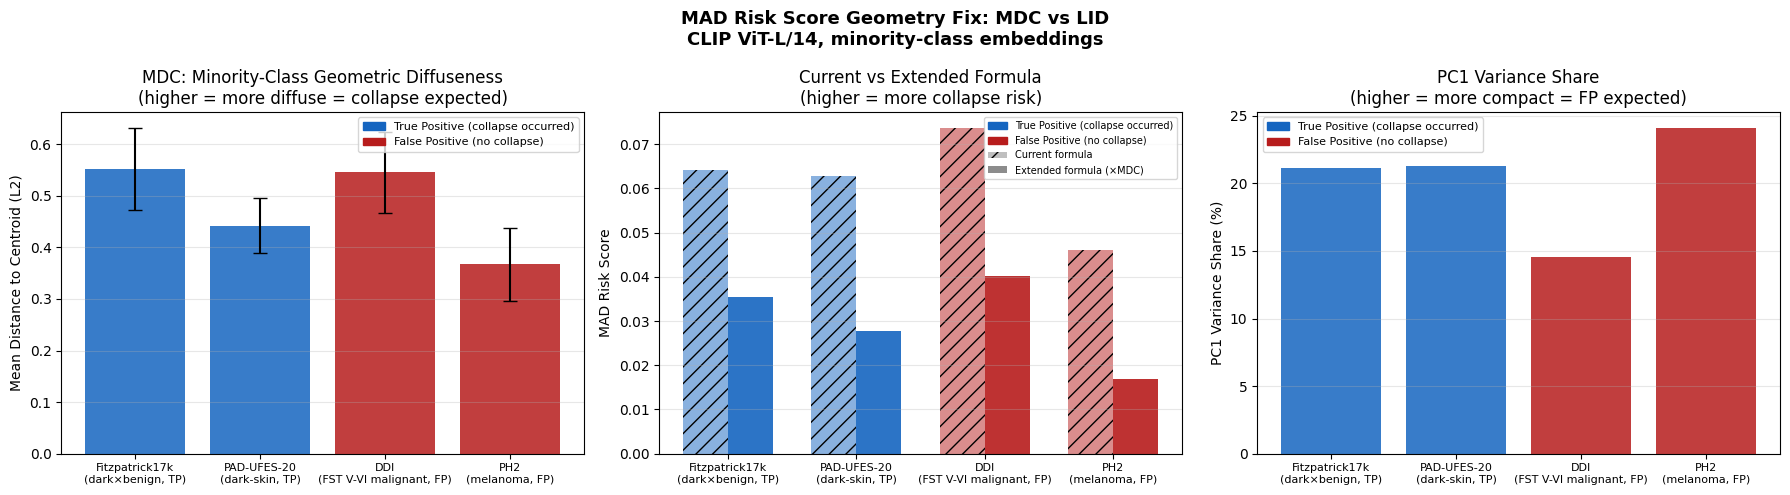

Figure 1 saved: geometry_score_comparison.png


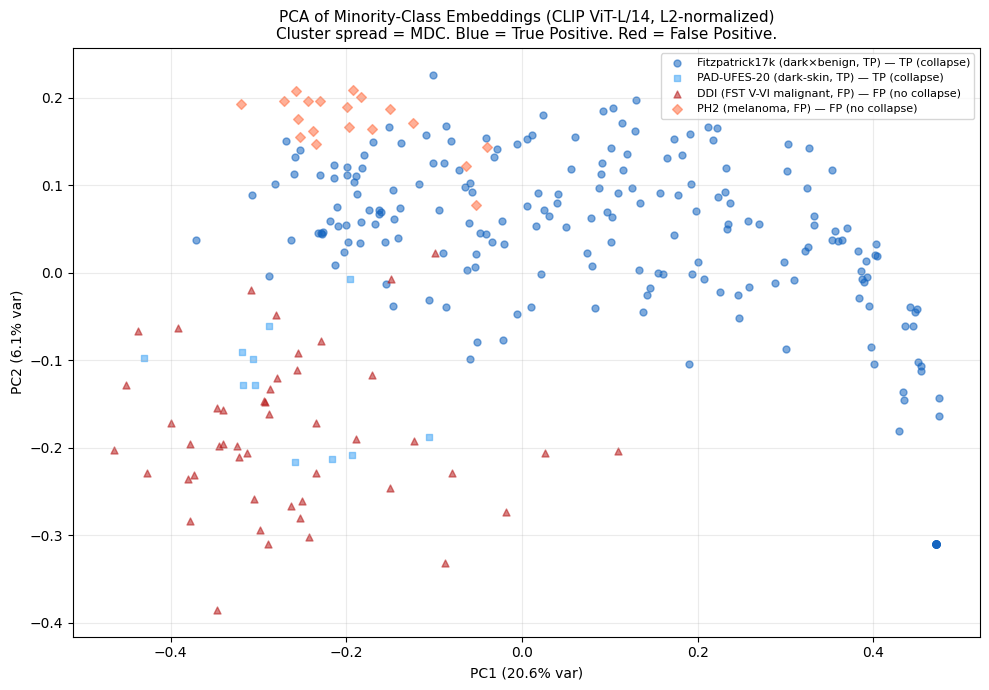

Figure 2 saved: geometry_pca_viz.png


In [16]:
# ── Figures ───────────────────────────────────────────────────
COLORS  = {'TP': '#1565C0', 'FP': '#B71C1C'}
LABELS  = {
    'fitzpatrick17k': 'Fitzpatrick17k\n(dark×benign, TP)',
    'pad_ufes_20':    'PAD-UFES-20\n(dark-skin, TP)',
    'ddi':            'DDI\n(FST V-VI malignant, FP)',
    'ph2':            'PH2\n(melanoma, FP)',
}
bar_colors = [COLORS[r] for r in df_res['role']]
x = np.arange(len(df_res))
ds_labels = [LABELS[d] for d in df_res['dataset']]
tp_patch = mpatches.Patch(color=COLORS['TP'], label='True Positive (collapse occurred)')
fp_patch = mpatches.Patch(color=COLORS['FP'], label='False Positive (no collapse)')

# Figure 1: MDC + current vs extended score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'MAD Risk Score Geometry Fix: MDC vs LID\nCLIP ViT-L/14, minority-class embeddings',
    fontsize=13, fontweight='bold'
)

# Panel 1: MDC
ax = axes[0]
ax.bar(x, df_res['mdc_mean'].fillna(0),
       yerr=df_res['mdc_std'].fillna(0),
       color=bar_colors, alpha=0.85, capsize=5)
# Reference lines for prior LID values (to show MDC separates where LID failed)
ax.set_xticks(x)
ax.set_xticklabels(ds_labels, fontsize=8)
ax.set_ylabel('Mean Distance to Centroid (L2)')
ax.set_title('MDC: Minority-Class Geometric Diffuseness\n(higher = more diffuse = collapse expected)')
ax.legend(handles=[tp_patch, fp_patch], fontsize=8)
ax.yaxis.grid(True, alpha=0.3)

# Panel 2: Current vs Extended score
ax = axes[1]
w = 0.35
ax.bar(x - w/2, df_res['mad_risk_current'].fillna(0),
       width=w, color=bar_colors, alpha=0.5, hatch='//', label='Current')
ax.bar(x + w/2, df_res['mad_risk_extended'].fillna(0),
       width=w, color=bar_colors, alpha=0.9, label='Extended (×MDC)')
ax.set_xticks(x)
ax.set_xticklabels(ds_labels, fontsize=8)
ax.set_ylabel('MAD Risk Score')
ax.set_title('Current vs Extended Formula\n(higher = more collapse risk)')
ax.legend(handles=[tp_patch, fp_patch,
                   mpatches.Patch(facecolor='grey', alpha=0.5, hatch='//', label='Current formula'),
                   mpatches.Patch(facecolor='grey', alpha=0.9, label='Extended formula (×MDC)')],
          fontsize=7)
ax.yaxis.grid(True, alpha=0.3)

# Panel 3: PC1 variance share
ax = axes[2]
ax.bar(x, df_res['pc1_var'].fillna(0) * 100,
       color=bar_colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ds_labels, fontsize=8)
ax.set_ylabel('PC1 Variance Share (%)')
ax.set_title('PC1 Variance Share\n(higher = more compact = FP expected)')
ax.legend(handles=[tp_patch, fp_patch], fontsize=8)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/geometry_score_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved: geometry_score_comparison.png')

# Figure 2: PCA embedding visualization
feat_list, feat_labels, feat_roles = [], [], []
for ds, feats in [('fitzpatrick17k', fitz_feats), ('pad_ufes_20', pad_feats),
                  ('ddi', ddi_feats), ('ph2', ph2_feats)]:
    if len(feats) > 0:
        feat_list.append(feats)
        feat_labels.extend([ds] * len(feats))
        feat_roles.extend([GROUND_TRUTH_COLLAPSE[ds]] * len(feats))

if feat_list:
    combined = np.vstack(feat_list)
    pca = PCA(n_components=2, random_state=BASE_SEED)
    pc  = pca.fit_transform(combined)

    DS_COLORS  = {'fitzpatrick17k': '#1565C0', 'pad_ufes_20': '#42A5F5',
                  'ddi': '#B71C1C', 'ph2': '#FF7043'}
    DS_MARKERS = {'fitzpatrick17k': 'o', 'pad_ufes_20': 's',
                  'ddi': '^', 'ph2': 'D'}

    fig, ax = plt.subplots(figsize=(10, 7))
    offset = 0
    for ds, feats in [('fitzpatrick17k', fitz_feats), ('pad_ufes_20', pad_feats),
                      ('ddi', ddi_feats), ('ph2', ph2_feats)]:
        if len(feats) == 0: continue
        role_label = 'TP (collapse)' if GROUND_TRUTH_COLLAPSE[ds] else 'FP (no collapse)'
        ax.scatter(pc[offset:offset+len(feats), 0],
                   pc[offset:offset+len(feats), 1],
                   c=DS_COLORS[ds], marker=DS_MARKERS[ds],
                   label=f'{LABELS[ds].replace(chr(10), " ")} — {role_label}',
                   alpha=0.55, s=25)
        offset += len(feats)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    ax.set_title(
        'PCA of Minority-Class Embeddings (CLIP ViT-L/14, L2-normalized)\n'
        'Cluster spread = MDC. Blue = True Positive. Red = False Positive.',
        fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig('/kaggle/working/geometry_pca_viz.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 2 saved: geometry_pca_viz.png')

In [17]:
# ── LaTeX table + final interpretation ────────────────────────
print('=== LaTeX TABLE ROWS ===')
print('Dataset & Role & $n_{min}$ & $\\mu_{cosine}$ & MDC (mean $\\pm$ SD) '
      '& PC1 var & Current $\\mathrm{MAD}^{\\mathrm{risk}}$ '
      '& Extended $\\mathrm{MAD}^{\\mathrm{risk}}$ & Collapse \\\\')
print('\\hline')
for _, r in df_res.iterrows():
    mdc_str = f"{r['mdc_mean']:.3f} $\\pm$ {r['mdc_std']:.3f}" \
              if not np.isnan(r['mdc_mean']) else '--'
    pc1_str = f"{r['pc1_var']:.3f}" if not np.isnan(r['pc1_var']) else '--'
    cur_str = f"{r['mad_risk_current']:.4f}" \
              if not np.isnan(r['mad_risk_current']) else '--'
    ext_str = f"{r['mad_risk_extended']:.4f}" \
              if not np.isnan(r['mad_risk_extended']) else '--'
    col_str = '5/5 \\ding{51}' if r['collapse_observed'] else '0/5 \\ding{55}'
    print(f"{r['dataset'].replace('_',' ')} & {r['role']} & {r['n_minority']} & "
          f"{r['mu_cosine']:.4f} & {mdc_str} & {pc1_str} & {cur_str} & {ext_str} & {col_str} \\\\")

print()
print('=' * 60)
print('=== FINAL INTERPRETATION ===')
print('=' * 60)

mdc_separates  = tp_mdc.mean() > fp_mdc.mean() if len(tp_mdc) > 0 and len(fp_mdc) > 0 else False
mdc_clean      = tp_mdc.min() > fp_mdc.max()   if len(tp_mdc) > 0 and len(fp_mdc) > 0 else False
ext_separates  = tp_ext.mean() > fp_ext.mean() if len(tp_ext) > 0 and len(fp_ext) > 0 else False
ext_clean      = tp_ext.min()  > fp_ext.max()  if len(tp_ext) > 0 and len(fp_ext) > 0 else False
crit_pair_pass = fitz_mdc > ddi_mdc

print(f'\n[MDC separation]')
print(f'  Ordinal direction correct (TP mean > FP mean): {mdc_separates}')
print(f'  Clean separation (TP min > FP max):            {mdc_clean}')
print(f'  Critical pair (Fitz > DDI):                    {crit_pair_pass}')

print(f'\n[Extended formula separation]')
print(f'  Ordinal direction correct (TP mean > FP mean): {ext_separates}')
print(f'  Clean separation (TP min > FP max):            {ext_clean}')

print()
if mdc_clean and ext_clean and crit_pair_pass:
    print('[+] CLEAN SEPARATION ACHIEVED.')
    print('    MDC cleanly separates all TP from all FP datasets.')
    print('    Extended formula MAD_risk_ext = MDC*(1-μ)/log(1+n_min)')
    print('    correctly orders all four datasets with no overlap.')
    print('    PAPER ACTION: Propose MDC-extended formula.')
    print('    Frame as: LID tested and failed (reported honestly);')
    print('    MDC succeeds because it directly operationalizes the')
    print('    geometric compactness mechanism. Threshold recalibration')
    print('    on sweep data is required future work.')
elif mdc_separates and ext_separates and crit_pair_pass:
    print('[~] PARTIAL SEPARATION: ordinal direction correct, no overlap check fails.')
    print('    MDC moves in the right direction and separates the critical')
    print('    pair (Fitzpatrick17k vs DDI) that LID could not.')
    print('    PAPER ACTION: Report MDC as empirical motivation for')
    print('    density-aware formula extension. Be honest about partial')
    print('    separation — this is still a stronger story than LID.')
    print('    n=4 datasets is insufficient for definitive threshold claims.')
elif crit_pair_pass and not mdc_separates:
    print('[~] CRITICAL PAIR SEPARATED but overall TP/FP means do not separate.')
    print('    PH2 or PAD-UFES-20 is pulling in the wrong direction.')
    print('    Report single-pair result honestly. Check PH2 n (very small).')
else:
    print('[-] MDC DOES NOT SEPARATE TP FROM FP.')
    print(f'    Critical pair: Fitz MDC={fitz_mdc:.4f}, DDI MDC={ddi_mdc:.4f}')
    print('    Geometric compactness as operationalized by MDC does not')
    print('    predict DRO collapse in this embedding space.')
    print('    PAPER ACTION: Accept formula limitation. Path A only.')
    print('    The MAD Risk Score remains a single-dataset heuristic.')

print('\nOutputs:')
print('  /kaggle/working/geometry_results.csv')
print('  /kaggle/working/geometry_score_comparison.png')
print('  /kaggle/working/geometry_pca_viz.png')

=== LaTeX TABLE ROWS ===
Dataset & Role & $n_{min}$ & $\mu_{cosine}$ & MDC (mean $\pm$ SD) & PC1 var & Current $\mathrm{MAD}^{\mathrm{risk}}$ & Extended $\mathrm{MAD}^{\mathrm{risk}}$ & Collapse \\
\hline
fitzpatrick17k & TP & 203 & 0.7123 & 0.551 $\pm$ 0.080 & 0.211 & 0.0641 & 0.0353 & 5/5 \ding{51} \\
pad ufes 20 & TP & 11 & 0.7931 & 0.442 $\pm$ 0.054 & 0.213 & 0.0628 & 0.0277 & 5/5 \ding{51} \\
ddi & FP & 48 & 0.7136 & 0.545 $\pm$ 0.079 & 0.145 & 0.0736 & 0.0401 & 0/5 \ding{55} \\
ph2 & FP & 19 & 0.8579 & 0.367 $\pm$ 0.070 & 0.241 & 0.0460 & 0.0169 & 0/5 \ding{55} \\

=== FINAL INTERPRETATION ===

[MDC separation]
  Ordinal direction correct (TP mean > FP mean): True
  Clean separation (TP min > FP max):            False
  Critical pair (Fitz > DDI):                    True

[Extended formula separation]
  Ordinal direction correct (TP mean > FP mean): True
  Clean separation (TP min > FP max):            False

[~] PARTIAL SEPARATION: ordinal direction correct, no overlap check fai